# Taxi Tabular Q-Learning

## 实验目标

本实验使用表格型 `Q-Learning` 求解 Taxi，目标是让智能体逐步学会在离散网格环境中完成完整任务闭环：找到乘客、正确接客、规划运输路径，并在目标位置正确下客。这个实验的重点不是追求复杂模型，而是把带阶段约束的离散任务如何通过价值学习被逐步拆解清楚。


## 为什么这里选择 Q-Learning

Taxi 是一个非常典型的表格型强化学习环境：

- 状态空间有限，可以直接用一张 Q 表存储状态-动作价值
- 动作空间离散，不需要连续控制算法
- 奖励结构明确，既有逐步移动代价，也有非法动作惩罚和任务完成奖励
- 任务天然分为接客和送客两个阶段，非常适合观察价值学习如何编码阶段性决策

因此，这里优先使用 `Tabular Q-Learning`，是为了把强化学习里最基础、也最有代表性的价值更新逻辑讲清楚。


## 收敛判断方式

这个 notebook 不会笼统地说“训练完成”，而是通过几组具体信号判断策略是否已经进入稳定阶段：

- 滚动平均回报是否持续改善
- 滚动成功率是否显著高于随机基线
- 非法动作频率是否逐步下降
- `epsilon` 是否按预期从高探索衰减到较低水平
- 最终贪心轨迹是否能够稳定完成完整任务链

只有这些信号同时成立，才说明 `Q-Learning` 不是偶然完成任务，而是真的学到了环境里的阶段结构。


## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是本实验没有神经网络，更新对象只是一张 Q 表。这里的重点是把状态-动作价值如何逐步成形讲清楚，而不是追求设备吞吐。


In [1]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [2]:
ENV_ID = "Taxi-v3"
NUM_EPISODES = 25000
MAX_STEPS = 200
LEARNING_RATE = 0.1
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.9998
ROLLING_WINDOW = 200
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)
num_states = env.observation_space.n
num_actions = env.action_space.n
q_table = np.zeros((num_states, num_actions), dtype=np.float32)


## 参数选择说明

这里的参数是按 Taxi 这种小规模离散任务来配的，重点是让训练过程稳定、结果清晰：

- `NUM_EPISODES = 25000`：给表格方法足够训练预算，保证接客和送客两个阶段都能反复覆盖
- `LEARNING_RATE = 0.1`：作为表格方法的稳妥起点，更新不会过于剧烈
- `GAMMA = 0.99`：Taxi 的最终奖励属于较长期目标，需要保持较高未来回报权重
- `EPSILON_START = 1.0`：训练初期充分探索
- `EPSILON_END = 0.05`：训练后期仍保留少量探索，避免过早固定在次优行为上
- `EPSILON_DECAY = 0.9998`：让探索衰减更平缓，使关键状态组合被充分访问
- `ROLLING_WINDOW = 200`：平滑训练曲线，便于观察趋势

如果训练后成功率仍不稳定，优先调整的方向通常是：

- 增加训练回合数
- 放慢 epsilon 衰减
- 微调学习率


In [3]:
def epsilon_greedy_action(q_values, state, epsilon, action_space):
    if np.random.random() < epsilon:
        return action_space.sample()
    return int(np.argmax(q_values[state]))


def decode_state(env_obj, state):
    taxi_row, taxi_col, passenger_location, destination = env_obj.unwrapped.decode(state)
    return {
        "taxi_row": int(taxi_row),
        "taxi_col": int(taxi_col),
        "passenger_location": int(passenger_location),
        "destination": int(destination),
    }


In [4]:
epsilon = EPSILON_START
episode_rewards = []
episode_successes = []
illegal_action_counts = []
epsilons = []
episode_lengths = []

for episode in tqdm(range(NUM_EPISODES), desc="Q-Learning episodes"):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    illegal_actions = 0

    for step in range(MAX_STEPS):
        action = epsilon_greedy_action(q_table, state, epsilon, env.action_space)
        next_state, reward, terminated, truncated, info = env.step(action)

        if reward == -10:
            illegal_actions += 1

        best_next_q = np.max(q_table[next_state])
        td_target = reward + GAMMA * best_next_q * (1 - int(terminated or truncated))
        td_error = td_target - q_table[state, action]
        q_table[state, action] += LEARNING_RATE * td_error

        state = next_state
        total_reward += reward

        if terminated or truncated:
            episode_lengths.append(step + 1)
            episode_success = int(terminated and reward == 20)
            break
    else:
        episode_lengths.append(MAX_STEPS)
        episode_success = 0

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    epsilons.append(epsilon)
    episode_rewards.append(total_reward)
    episode_successes.append(episode_success)
    illegal_action_counts.append(illegal_actions)

env.close()


Q-Learning episodes:   0%|          | 0/25000 [00:00<?, ?it/s]

In [5]:
reward_series = pd.Series(episode_rewards)
success_series = pd.Series(episode_successes)
illegal_series = pd.Series(illegal_action_counts)
epsilon_series = pd.Series(epsilons)

rolling_reward = reward_series.rolling(ROLLING_WINDOW).mean()
rolling_success = success_series.rolling(ROLLING_WINDOW).mean()
rolling_illegal = illegal_series.rolling(ROLLING_WINDOW).mean()


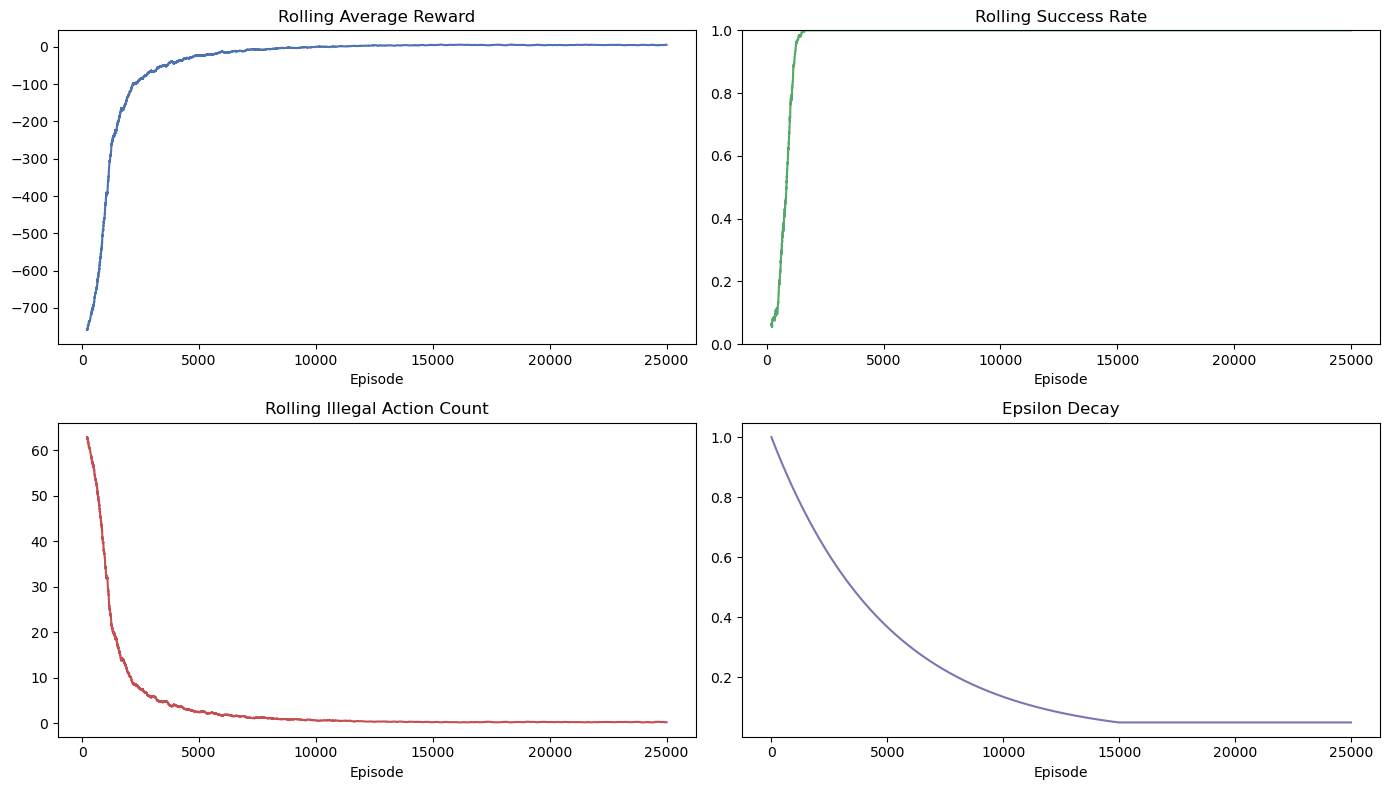

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(rolling_reward, color="#4c72b0")
axes[0, 0].set_title("Rolling Average Reward")
axes[0, 0].set_xlabel("Episode")

axes[0, 1].plot(rolling_success, color="#55a868")
axes[0, 1].set_title("Rolling Success Rate")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylim(0, 1)

axes[1, 0].plot(rolling_illegal, color="#c44e52")
axes[1, 0].set_title("Rolling Illegal Action Count")
axes[1, 0].set_xlabel("Episode")

axes[1, 1].plot(epsilon_series, color="#8172b3")
axes[1, 1].set_title("Epsilon Decay")
axes[1, 1].set_xlabel("Episode")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "q_learning_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
def build_phase_maps(q_values, env_id, passenger_location, destination):
    phase_values = np.zeros((5, 5), dtype=float)
    phase_actions = np.empty((5, 5), dtype=object)
    eval_env = gym.make(env_id)
    action_symbols = np.array(["S", "N", "E", "W", "P", "D"])

    for row in range(5):
        for col in range(5):
            state = eval_env.unwrapped.encode(row, col, passenger_location, destination)
            phase_values[row, col] = float(np.max(q_values[state]))
            phase_actions[row, col] = action_symbols[int(np.argmax(q_values[state]))]

    eval_env.close()
    return phase_values, phase_actions


pickup_values, pickup_actions = build_phase_maps(q_table, ENV_ID, passenger_location=0, destination=1)
delivery_values, delivery_actions = build_phase_maps(q_table, ENV_ID, passenger_location=4, destination=1)


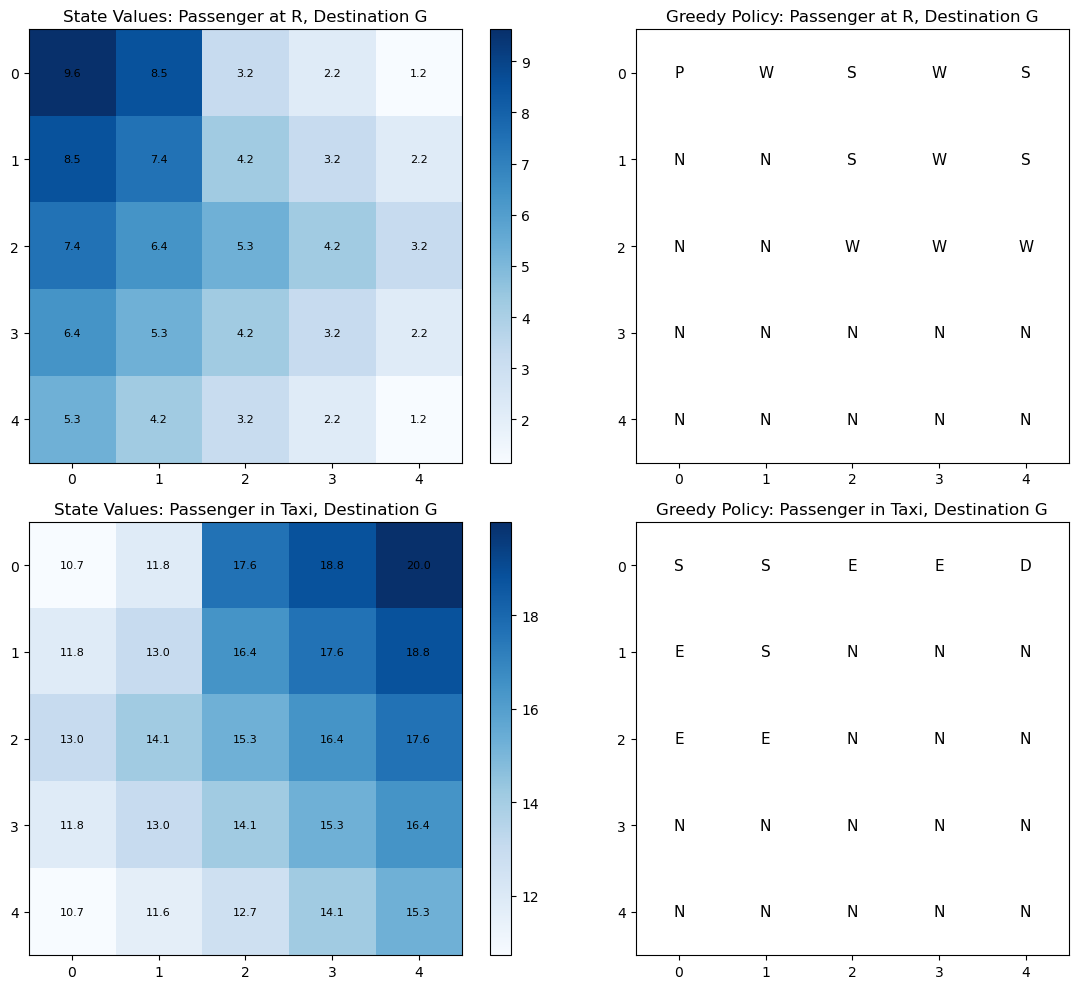

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

im1 = axes[0, 0].imshow(pickup_values, cmap="Blues")
axes[0, 0].set_title("State Values: Passenger at R, Destination G")
for i in range(5):
    for j in range(5):
        axes[0, 0].text(j, i, f"{pickup_values[i, j]:.1f}", ha="center", va="center", color="black", fontsize=8)
fig.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].imshow(np.zeros((5, 5)), cmap="Greys", vmin=0, vmax=1)
axes[0, 1].set_title("Greedy Policy: Passenger at R, Destination G")
for i in range(5):
    for j in range(5):
        axes[0, 1].text(j, i, pickup_actions[i, j], ha="center", va="center", color="black", fontsize=11)

im2 = axes[1, 0].imshow(delivery_values, cmap="Blues")
axes[1, 0].set_title("State Values: Passenger in Taxi, Destination G")
for i in range(5):
    for j in range(5):
        axes[1, 0].text(j, i, f"{delivery_values[i, j]:.1f}", ha="center", va="center", color="black", fontsize=8)
fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(np.zeros((5, 5)), cmap="Greys", vmin=0, vmax=1)
axes[1, 1].set_title("Greedy Policy: Passenger in Taxi, Destination G")
for i in range(5):
    for j in range(5):
        axes[1, 1].text(j, i, delivery_actions[i, j], ha="center", va="center", color="black", fontsize=11)

for ax in axes.flat:
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "q_learning_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
def greedy_rollout(q_values, env_id, max_steps=200, seed=SEED + 100000):
    eval_env = gym.make(env_id)
    state, info = eval_env.reset(seed=seed)
    action_names = ["south", "north", "east", "west", "pickup", "dropoff"]
    trajectory = []
    total_reward = 0.0
    illegal_actions = 0

    for step in range(max_steps):
        state_info = decode_state(eval_env, state)
        action = int(np.argmax(q_values[state]))
        next_state, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        if reward == -10:
            illegal_actions += 1
        trajectory.append(
            {
                "step": step,
                **state_info,
                "action": action_names[action],
                "reward": reward,
                "next_state": int(next_state),
                "terminated": int(terminated),
                "truncated": int(truncated),
            }
        )
        state = next_state
        if terminated or truncated:
            eval_env.close()
            return {
                "greedy_return": total_reward,
                "greedy_steps": step + 1,
                "greedy_success": int(terminated and reward == 20),
                "greedy_illegal_actions": illegal_actions,
                "trajectory": trajectory,
            }

    eval_env.close()
    return {
        "greedy_return": total_reward,
        "greedy_steps": max_steps,
        "greedy_success": 0,
        "greedy_illegal_actions": illegal_actions,
        "trajectory": trajectory,
    }


greedy_eval = greedy_rollout(q_table, ENV_ID, max_steps=MAX_STEPS)
greedy_eval


{'greedy_return': 8.0,
 'greedy_steps': 13,
 'greedy_success': 1,
 'greedy_illegal_actions': 0,
 'trajectory': [{'step': 0,
   'taxi_row': 1,
   'taxi_col': 4,
   'passenger_location': 3,
   'destination': 0,
   'action': 'west',
   'reward': -1,
   'next_state': 172,
   'terminated': 0,
   'truncated': 0},
  {'step': 1,
   'taxi_row': 1,
   'taxi_col': 3,
   'passenger_location': 3,
   'destination': 0,
   'action': 'south',
   'reward': -1,
   'next_state': 272,
   'terminated': 0,
   'truncated': 0},
  {'step': 2,
   'taxi_row': 2,
   'taxi_col': 3,
   'passenger_location': 3,
   'destination': 0,
   'action': 'south',
   'reward': -1,
   'next_state': 372,
   'terminated': 0,
   'truncated': 0},
  {'step': 3,
   'taxi_row': 3,
   'taxi_col': 3,
   'passenger_location': 3,
   'destination': 0,
   'action': 'south',
   'reward': -1,
   'next_state': 472,
   'terminated': 0,
   'truncated': 0},
  {'step': 4,
   'taxi_row': 4,
   'taxi_col': 3,
   'passenger_location': 3,
   'destinati

In [10]:
metrics = pd.DataFrame(
    {
        "metric": [
            "overall_success_rate",
            "average_reward",
            "average_episode_length",
            "average_illegal_actions",
            "final_epsilon",
            "greedy_eval_return",
            "greedy_eval_steps",
            "greedy_eval_success",
            "greedy_eval_illegal_actions",
        ],
        "value": [
            float(np.mean(episode_successes)),
            float(np.mean(episode_rewards)),
            float(np.mean(episode_lengths)),
            float(np.mean(illegal_action_counts)),
            float(epsilon),
            float(greedy_eval["greedy_return"]),
            float(greedy_eval["greedy_steps"]),
            float(greedy_eval["greedy_success"]),
            float(greedy_eval["greedy_illegal_actions"]),
        ],
    }
)
metrics


,metric,value
0,overall_success_rate,0.97200
1,average_reward,-37.91976
2,average_episode_length,25.36260
3,average_illegal_actions,3.66324
4,final_epsilon,0.05000
5,greedy_eval_return,8.00000
6,greedy_eval_steps,13.00000
7,greedy_eval_success,1.00000
8,greedy_eval_illegal_actions,0.00000


In [11]:
metrics.to_csv(RESULTS_DIR / "q_learning_metrics.csv", index=False)
pd.DataFrame(q_table).to_csv(RESULTS_DIR / "q_learning_q_table.csv", index=False)
pd.DataFrame(greedy_eval["trajectory"]).to_csv(RESULTS_DIR / "q_learning_greedy_trajectory.csv", index=False)

print(f"Overall success rate: {np.mean(episode_successes):.4f}")
print(f"Average reward: {np.mean(episode_rewards):.2f}")
print(f"Average episode length: {np.mean(episode_lengths):.2f}")
print(f"Average illegal actions: {np.mean(illegal_action_counts):.2f}")
print(f"Final epsilon: {epsilon:.4f}")
print(f"Greedy eval return: {greedy_eval['greedy_return']:.2f}")
print(f"Greedy eval steps: {greedy_eval['greedy_steps']}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Overall success rate: 0.9720
Average reward: -37.92
Average episode length: 25.36
Average illegal actions: 3.66
Final epsilon: 0.0500
Greedy eval return: 8.00
Greedy eval steps: 13
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/05-taxi-tabular-q-learning/results


## 结果解读

训练完成后，重点观察以下内容：

- 滚动平均回报是否逐渐改善
- 成功率是否从接近随机水平明显提升
- 非法动作次数是否持续下降
- `epsilon` 是否按预期逐步衰减
- 贪心轨迹是否能够稳定完成接客和送客两个阶段

如果这些现象都成立，就说明 `Q-Learning` 已经学到了 Taxi 的任务结构，而不仅仅是局部移动偏好。这个环境很适合说明：强化学习学到的不只是路径本身，还包括不同阶段下动作含义的变化。
